<a href="https://colab.research.google.com/github/mienye/Projects-/blob/main/Cost_sensitive_Oversampling_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#UNCOMMENT THE ABOVE TWO LINES WHEN RUNNING THIS CODE FOR THE FIST TIME
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/My Drive/Datasets/creditcard.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load Data
# df = pd.read_csv("creditcard.csv")
X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']
cost = df['Amount']

# Train/Test split
X_train, X_test, y_train, y_test, cost_train, cost_test = train_test_split(
    X, y, cost, test_size=0.3, stratify=y, random_state=42
)



In [ ]:
# Helper for cost-sensitive weights
def get_cost_weights(y, cost):
    fraud_idx = (y == 1)
    cost_fraud = cost[fraud_idx]
    weights = np.zeros_like(cost, dtype=np.float64)
    if cost_fraud.sum() > 0:
        weights[fraud_idx] = cost_fraud / cost_fraud.sum()
    return weights

def cost_sensitive_resample(X, y, cost, sampler_class):
    fraud_idx = (y == 1).values
    weights = get_cost_weights(y.values, cost.values)
    n_majority = sum(y == 0)
    total_new = n_majority - sum(y == 1)
    if total_new <= 0:
        return X, y
    reps = np.ceil(weights[fraud_idx] * total_new).astype(int)
    X_fraud = X[fraud_idx]
    y_fraud = y[fraud_idx]
    X_syn = pd.DataFrame(np.repeat(X_fraud.values, reps, axis=0), columns=X.columns)
    y_syn = pd.Series(np.repeat(y_fraud.values, reps), index=X_syn.index)
    X_aug = pd.concat([X, X_syn], axis=0, ignore_index=True)
    y_aug = pd.concat([y, y_syn], axis=0, ignore_index=True)
    sampler = sampler_class(sampling_strategy='auto', random_state=42)
    X_res, y_res = sampler.fit_resample(X_aug, y_aug)
    return X_res, y_res



In [ ]:
# Oversampling configs
samplers = [
    ("SMOTE", SMOTE),
    ("ADASYN", ADASYN),
    ("Borderline-SMOTE", BorderlineSMOTE),
    ("SMOTE-ENN", SMOTEENN),
    ("SMOTE-Tomek", SMOTETomek),
]

def apply_all_oversamplers(X, y, cost):
    results = {}
    for name, Sampler in samplers:
        # Standard
        sampler = Sampler(sampling_strategy='auto', random_state=42)
        X_std, y_std = sampler.fit_resample(X, y)
        results[name] = (X_std, y_std)
        # Cost-sensitive
        X_cs, y_cs = cost_sensitive_resample(X, y, cost, Sampler)
        results["Cost-sensitive " + name] = (X_cs, y_cs)
    return results




In [ ]:
# Prepare ML models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "MLP": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=10, random_state=42),  # You can increase max_iter for best results
    "Logistic Regression": LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)
}

# Performance metrics
def evaluate(y_true, y_pred, y_proba, cost_test, threshold=0.5):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_proba)
    # Total Cost Savings (vs no model)
    missed_fraud_cost_baseline = cost_test[y_true == 1].sum()
    missed_fraud_cost_model = cost_test[(y_true == 1) & (y_pred == 0)].sum()
    tcs = missed_fraud_cost_baseline - missed_fraud_cost_model
    acm = (missed_fraud_cost_model + fp * 1) / (fn + fp) if (fn + fp) > 0 else 0  # Set FP cost to 1 by default
    return acc, sens, spec, f1, tcs, acm, auc_score




Training model: Random Forest

Training model: XGBoost

Training model: LightGBM
[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.121818 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 199149, number of negative: 199149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.235284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7394
[LightGBM] [Info] Number of data points in the train set: 398298, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positi

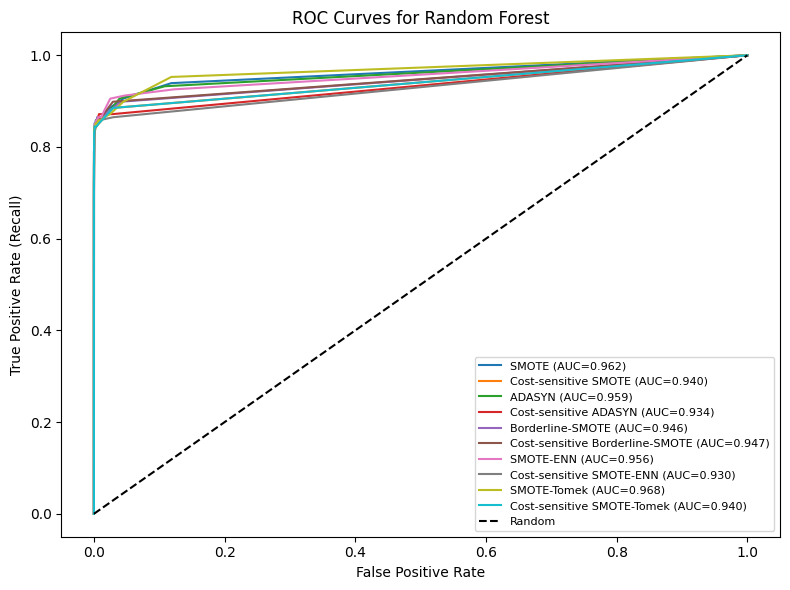

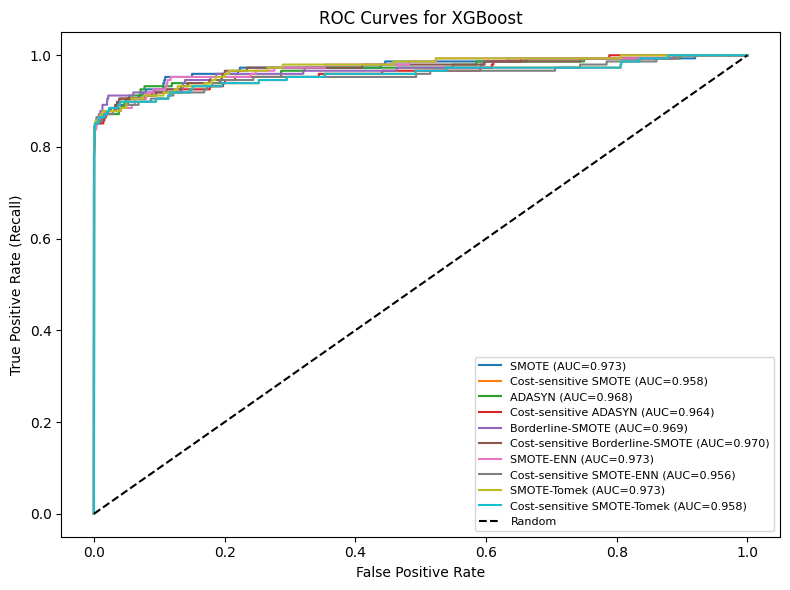

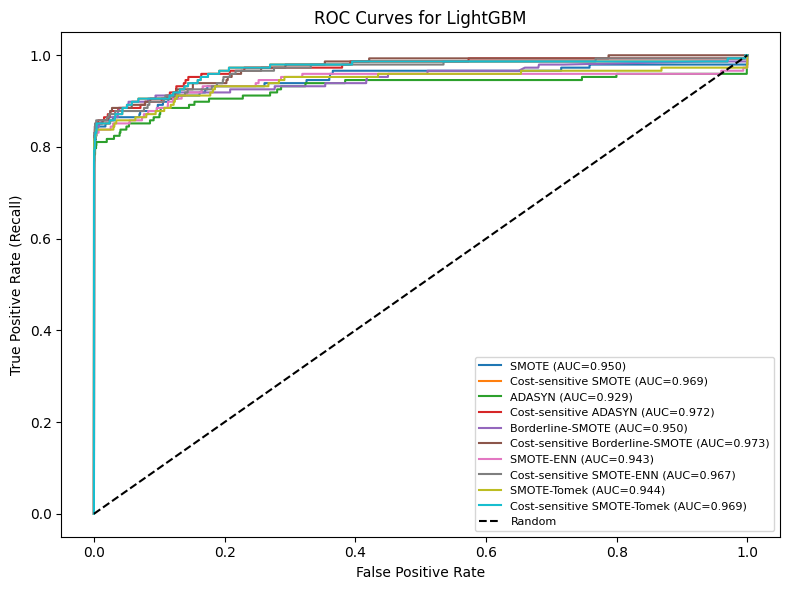

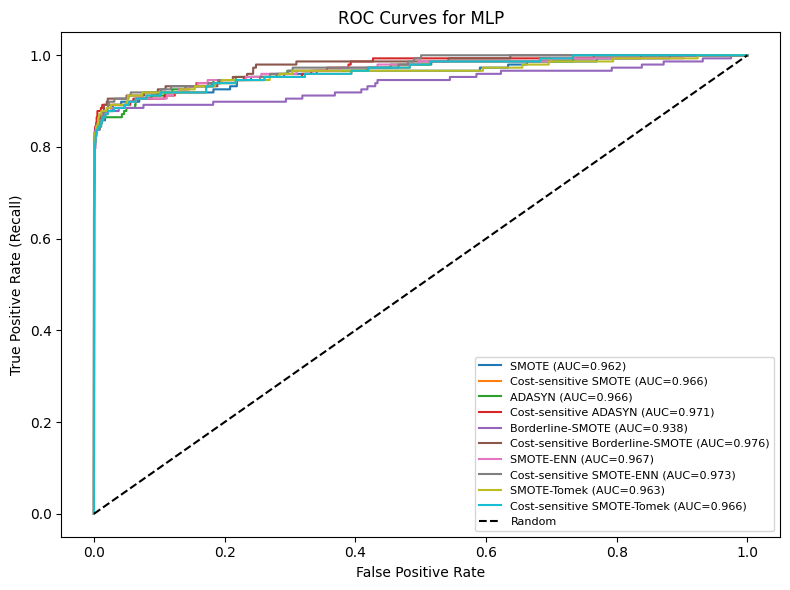

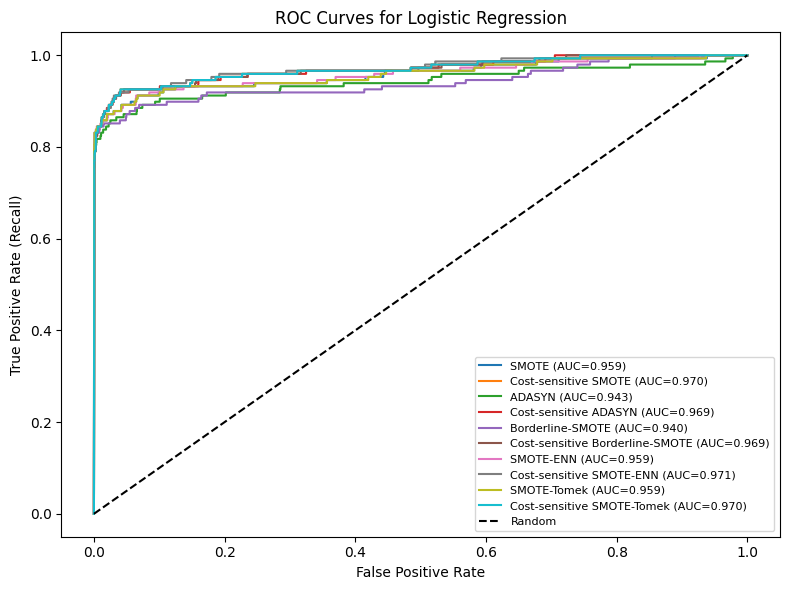

In [ ]:
# Final results storage
results_dict = {m: [] for m in models}
roc_curves = {m: {} for m in models}

# Apply all oversamplers to train set
oversampled_datasets = apply_all_oversamplers(X_train, y_train, cost_train)

for model_name, model in models.items():
    print(f"\nTraining model: {model_name}")
    for ov_name, (X_res, y_res) in oversampled_datasets.items():
        # Train model
        clf = model
        clf.fit(X_res, y_res)
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else clf.decision_function(X_test)
        metrics = evaluate(y_test, y_pred, y_proba, cost_test)
        # Store
        results_dict[model_name].append([ov_name] + list(metrics[:-1]))  # exclude AUC for tabulation
        # Store ROC curve for plotting
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_curves[model_name][ov_name] = (fpr, tpr, metrics[-1])  # AUC

# Display tables for each model
for model_name, rows in results_dict.items():
    table = pd.DataFrame(rows, columns=[
        "Oversampling", "Accuracy", "Sensitivity", "Specificity", "F1-Score", "Total Cost Savings", "Avg Cost/Misclass."
    ])
    print(f"\n=== {model_name} ===")
    print(table)

# Plot ROC curves for each model
for model_name, curves in roc_curves.items():
    plt.figure(figsize=(8,6))
    for name, (fpr, tpr, auc_val) in curves.items():
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.title(f"ROC Curves for {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()